# 🟠 Lesson 17 — Scikit-learn

**Level: Advanced** · Machine learning — classify rocks from geochemistry, cluster samples, predict grades.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn
print("scikit-learn", sklearn.__version__)

DATA = Path("..") / "data"
rocks = pd.read_csv(DATA / "rocks.csv").dropna()
oxides = [c for c in rocks.columns if c != "Name"]
print(rocks["Name"].value_counts())

scikit-learn 1.7.2
Name
basalt      7171
andesite    6271
rhyolite    4968
dacite      4027
Name: count, dtype: int64


## 1. Train/test split — never grade your own homework

In [2]:
from sklearn.model_selection import train_test_split

X = rocks[oxides]
y = rocks["Name"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (16827, 9) | test: (5610, 9)


## 2. Random forest — classify rock type from major oxides

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("accuracy: %.1f%%" % (100 * accuracy_score(y_test, pred)))
print(classification_report(y_test, pred))

accuracy: 90.8%
              precision    recall  f1-score   support

    andesite       0.89      0.90      0.89      1568
      basalt       0.95      0.95      0.95      1793
      dacite       0.84      0.82      0.83      1007
    rhyolite       0.92      0.93      0.93      1242

    accuracy                           0.91      5610
   macro avg       0.90      0.90      0.90      5610
weighted avg       0.91      0.91      0.91      5610



## 3. Which oxides matter most?

In [4]:
imp = pd.Series(clf.feature_importances_, index=oxides).sort_values(ascending=False)
print(imp.round(3))
print("\n-> as a petrologist would expect, SiO2 and the alkalis dominate.")

SiO2     0.355
CaO      0.150
FeOT     0.143
MgO      0.114
TiO2     0.093
Al2O3    0.051
K2O      0.035
MnO      0.032
Na2O     0.028
dtype: float64

-> as a petrologist would expect, SiO2 and the alkalis dominate.


## 4. Confusion matrix — where does it get confused?

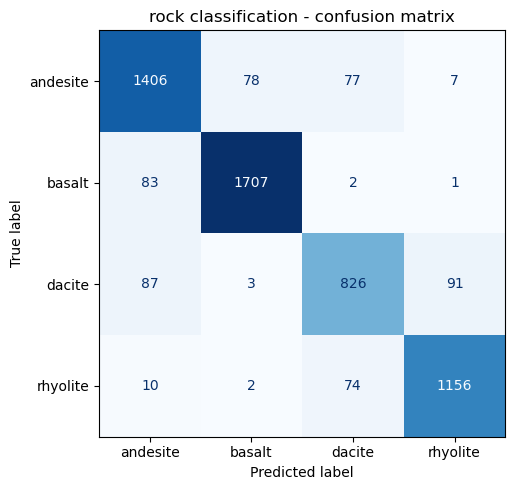

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("rock classification - confusion matrix")
plt.tight_layout(); plt.show()

## 5. Unsupervised — do the samples cluster naturally?
KMeans doesn't know the rock names; see if chemistry alone recovers them.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Xs = StandardScaler().fit_transform(X)          # scaling is essential for KMeans
km = KMeans(n_clusters=rocks["Name"].nunique(), random_state=42, n_init=10)
rocks["cluster"] = km.fit_predict(Xs)

print(pd.crosstab(rocks["Name"], rocks["cluster"]))

cluster      0     1     2   3
Name                          
andesite   191   941  5139   0
basalt      13  6385   760  13
dacite    1652    25  2350   0
rhyolite  4838    11   119   0


## 6. Predict a brand-new sample

In [7]:
new = pd.DataFrame([{"SiO2": 72.0, "Al2O3": 14.0, "CaO": 1.5, "Na2O": 3.8,
                     "K2O": 4.5, "FeOT": 1.8, "MgO": 0.4, "MnO": 0.05, "TiO2": 0.2}])
proba = clf.predict_proba(new[oxides])[0]
for name, p in sorted(zip(clf.classes_, proba), key=lambda t: -t[1]):
    print(f"{name:<12} {p:5.1%}")

rhyolite     84.7%
dacite       15.3%
andesite      0.0%
basalt        0.0%


### ✏️ Try it
1. Swap the random forest for `LogisticRegression` (scale first!) and compare accuracy.
2. Use `RandomForestRegressor` on the assay data: predict `AU_gpt` from Cu, Ag, Mo, As, S.

📚 Docs: https://scikit-learn.org/stable/